In [13]:
import setup_paths
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import config
from adni_dataset import ADNIDataset
from model import EarlyFusion3DCNN
from medical_net import MedicalNetTransfer
from train import compute_metrics, FocalLoss
from explainability import run_explainability
from generate_submission import generate_submission

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
from dataloader import get_dataloader
from sklearn.metrics import accuracy_score, roc_auc_score

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Sanity checks

In [5]:
print("--- RUNNING 10-SUBJECT SANITY CHECK ---")

# 1. Load the dataset and grab only the first 10 subjects
full_train_dataset = ADNIDataset(
    config.SPLIT_LAB_CSV, "train_sessions", config.PREPROCESSED_DIR, use_preprocessed=True)
mini_dataset = Subset(full_train_dataset, range(10))
mini_loader = DataLoader(mini_dataset, batch_size=2, shuffle=True)

# 2. Initialize a fresh model and optimizer
model = EarlyFusion3DCNN(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Train for 3 Epochs
model.train()
for epoch in range(1, 4):
    epoch_loss = 0.0
    for x, y, _ in mini_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch} | Mini-Batch Loss: {epoch_loss:.4f}")

--- RUNNING 10-SUBJECT SANITY CHECK ---
Epoch 1 | Mini-Batch Loss: 7.4287
Epoch 2 | Mini-Batch Loss: 6.3598
Epoch 3 | Mini-Batch Loss: 5.7423


The loss decreased and no NaNs appeared, so the code is ready for the full training

In [6]:
print("--- RUNNING END-TO-END SANITY CHECK ---")

# 1. Load Datasets and create TINY subsets
full_train = ADNIDataset(config.SPLIT_LAB_CSV, "train_sessions",
                         config.PREPROCESSED_DIR, use_preprocessed=True)
full_val = ADNIDataset(config.SPLIT_LAB_CSV, "eval_sessions",
                       config.PREPROCESSED_DIR, use_preprocessed=True)

# Grab 10 subjects for training, 6 subjects for validation
mini_train_loader = DataLoader(
    Subset(full_train, range(10)), batch_size=2, shuffle=True)
mini_val_loader = DataLoader(
    Subset(full_val, range(6)), batch_size=2, shuffle=False)

# 2. Initialize Model, Loss, and Optimizer
model = EarlyFusion3DCNN(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Mini Training & Validation Loop
for epoch in range(1, 4):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for x, y, _ in mini_train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    all_y_true, all_y_pred, all_y_prob = [], [], []

    with torch.no_grad():
        for x, y, _ in mini_val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_y_true.extend(y.cpu().numpy())
            all_y_pred.extend(preds.cpu().numpy())
            all_y_prob.extend(probs.cpu().numpy())

    # Calculate Metrics
    acc, bal_acc, mac_prec, mac_rec, mac_f1, mac_spec, auc = compute_metrics(
        np.array(all_y_true), np.array(all_y_pred), np.array(all_y_prob)
    )

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Bal-Acc: {bal_acc:.4f} | AUC: {auc:.4f}")

--- RUNNING END-TO-END SANITY CHECK ---
Epoch 1 | Train Loss: 5.3145 | Val Loss: 3.0553 | Val Bal-Acc: 0.5000 | AUC: 0.5000
Epoch 2 | Train Loss: 4.7979 | Val Loss: 2.7709 | Val Bal-Acc: 0.5000 | AUC: 0.5000
Epoch 3 | Train Loss: 4.6068 | Val Loss: 2.6259 | Val Bal-Acc: 0.5000 | AUC: 0.5000


The metrics were printed successfully without crashing, so the entire pipeline is safe to run.

### Full training

In [ ]:
# from train import train_model

# print("--- STARTING FULL TRAINING ---")
# train_model()

## baseline_3dcnn

### Evaluation

--- EVALUATING MODEL ---


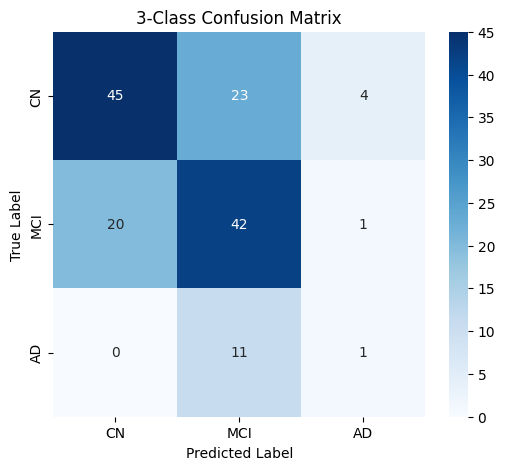

In [3]:
print("--- EVALUATING MODEL ---")
# Load the Model
model = EarlyFusion3DCNN(num_classes=3).to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / "baseline_3dcnn.pt"))
model.eval()

# Get Test Data
test_loader = get_dataloader("test_sessions", config.SPLIT_LAB_CSV, config.PREPROCESSED_DIR, batch_size=4, augment=False)

all_y_true, all_y_pred, all_y_prob = [], [], []

# Run Inference
with torch.no_grad():
    for x, y, _ in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_y_true.extend(y.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())
        all_y_prob.extend(probs.cpu().numpy())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

# Plot Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CN", "MCI", "AD"], yticklabels=["CN", "MCI", "AD"])
plt.title("3-Class Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Binary tasks

In [16]:
def evaluate_binary_task(y_true, y_prob, class_A, class_B, name_A, name_B):
    # 1. Filter out the third class
    mask = (y_true == class_A) | (y_true == class_B)
    y_t_filtered = y_true[mask]
    y_p_filtered = y_prob[mask]
    
    if len(y_t_filtered) == 0:
        return
        
    # 2. Re-normalize probabilities for just these two classes
    # e.g., prob_MCI / (prob_CN + prob_MCI)
    prob_A = y_p_filtered[:, class_A]
    prob_B = y_p_filtered[:, class_B]
    prob_normalized_B = prob_B / (prob_A + prob_B + 1e-7)
    
    # 3. Create binary labels (0 for Class A, 1 for Class B)
    y_t_binary = (y_t_filtered == class_B).astype(int)
    y_pred_binary = (prob_normalized_B >= 0.5).astype(int)
    
    # 4. Calculate Metrics
    acc = accuracy_score(y_t_binary, y_pred_binary)
    
    # Check if both classes are present in the validation split to avoid AUC crash
    if len(np.unique(y_t_binary)) > 1:
        auc = roc_auc_score(y_t_binary, prob_normalized_B)
    else:
        auc = float('nan')
        
    print(f"--- {name_A} vs {name_B} ---")
    print(f"Accuracy: {acc:.4f} | AUC: {auc:.4f}\n")

In [5]:
print("====================================")
print("BINARY TASK EVALUATION (Thresholded)")
print("====================================")
evaluate_binary_task(all_y_true, all_y_prob, 0, 1, "CN", "MCI")
evaluate_binary_task(all_y_true, all_y_prob, 1, 2, "MCI", "AD")
evaluate_binary_task(all_y_true, all_y_prob, 0, 2, "CN", "AD")

BINARY TASK EVALUATION (Thresholded)
--- CN vs MCI ---
Accuracy: 0.6519 | AUC: 0.6554

--- MCI vs AD ---
Accuracy: 0.8400 | AUC: 0.8770

--- CN vs AD ---
Accuracy: 0.8214 | AUC: 0.8634



### Explainability

(Have to look specifically at whether the highlighted regions correspond to clinically meaningful areas: for AD you expect activation near the hippocampus and temporal lobe, for MCI you expect subtle entorhinal/medial temporal activations, and for CN you expect minimal activation.)

In [6]:
run_explainability(experiment_name="baseline_3dcnn")

--- GENERATING Grad-CAM EXPLANATIONS FOR 'baseline_3dcnn' ON cuda ---
Searching for correctly classified subjects...
[CN] Found match: 003_S_10622_sc. Generating heatmap...
[CN] Found match: 005_S_10101_sc. Generating heatmap...
[CN] Found match: 005_S_10646_sc. Generating heatmap...
[MCI] Found match: 006_S_4713_init. Generating heatmap...
[MCI] Found match: 006_S_4713_m12. Generating heatmap...
[CN] Found match: 007_S_10258_sc. Generating heatmap...
[CN] Found match: 007_S_6455_init. Generating heatmap...
[MCI] Found match: 011_S_10483_sc. Generating heatmap...
[MCI] Found match: 016_S_10885_sc. Generating heatmap...
[MCI] Found match: 016_S_6809_init. Generating heatmap...
[AD] Found match: 941_S_10001_sc. Generating heatmap...

Finished! Heatmaps saved to: C:\Users\leoma\Desktop\Computer Vision\Project\outputs\explainability\gradcam\baseline_3dcnn


### Generating the submission CSV

In [7]:
generate_submission(experiment_name="baseline_3dcnn")

--- GENERATING FINAL SUBMISSIONS FOR 'baseline_3dcnn' ON cuda ---
All constraints verified successfully.
Saved Ternary CSV to: baseline_3dcnn/submission_ternary.csv
Saved Binary CSV: submission_binary_CN_vs_MCI.csv
Saved Binary CSV: submission_binary_MCI_vs_AD.csv
Saved Binary CSV: submission_binary_CN_vs_AD.csv

FINAL TEST SET EVALUATION: baseline_3dcnn
Accuracy:           0.5986
Balanced Accuracy:  0.4583
Macro Precision:    0.4705
Macro Recall:       0.4583
Macro F1-Score:     0.4575
Macro Specificity:  0.7638
AUC (OVR):          0.7327



## focal_3dcnn

--- EVALUATING MODEL ---


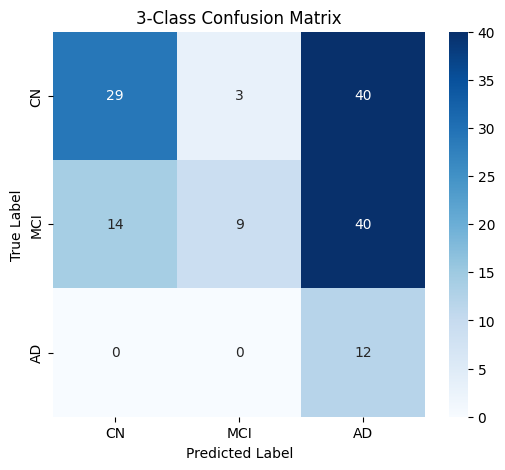

In [8]:
print("--- EVALUATING MODEL ---")
# Load the Model
model = EarlyFusion3DCNN(num_classes=3).to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / "focal_3dcnn.pt"))
model.eval()

# Get Test Data
test_loader = get_dataloader("test_sessions", config.SPLIT_LAB_CSV, config.PREPROCESSED_DIR, batch_size=4, augment=False)

all_y_true, all_y_pred, all_y_prob = [], [], []

# Run Inference
with torch.no_grad():
    for x, y, _ in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_y_true.extend(y.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())
        all_y_prob.extend(probs.cpu().numpy())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

# Plot Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CN", "MCI", "AD"], yticklabels=["CN", "MCI", "AD"])
plt.title("3-Class Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
print("====================================")
print("BINARY TASK EVALUATION (Thresholded)")
print("====================================")
evaluate_binary_task(all_y_true, all_y_prob, 0, 1, "CN", "MCI")
evaluate_binary_task(all_y_true, all_y_prob, 1, 2, "MCI", "AD")
evaluate_binary_task(all_y_true, all_y_prob, 0, 2, "CN", "AD")

BINARY TASK EVALUATION (Thresholded)
--- CN vs MCI ---
Accuracy: 0.5852 | AUC: 0.6131

--- MCI vs AD ---
Accuracy: 0.4667 | AUC: 0.8704

--- CN vs AD ---
Accuracy: 0.5238 | AUC: 0.8449



In [10]:
run_explainability(experiment_name="focal_3dcnn")

--- GENERATING Grad-CAM EXPLANATIONS FOR 'focal_3dcnn' ON cuda ---
Searching for correctly classified subjects...
[CN] Found match: 003_S_10622_sc. Generating heatmap...
[CN] Found match: 005_S_10101_sc. Generating heatmap...
[MCI] Found match: 006_S_4713_init. Generating heatmap...
[CN] Found match: 007_S_10258_sc. Generating heatmap...
[CN] Found match: 011_S_10278_sc. Generating heatmap...
[CN] Found match: 012_S_10312_sc. Generating heatmap...
[MCI] Found match: 022_S_10381_sc. Generating heatmap...
[MCI] Found match: 023_S_4115_init. Generating heatmap...
[AD] Found match: 033_S_10021_m12. Generating heatmap...
[AD] Found match: 033_S_10021_m24. Generating heatmap...
[AD] Found match: 033_S_10021_sc. Generating heatmap...
[AD] Found match: 033_S_10049_sc. Generating heatmap...
[AD] Found match: 033_S_10144_m12. Generating heatmap...
[MCI] Found match: 036_S_10165_sc. Generating heatmap...
[MCI] Found match: 082_S_10777_sc. Generating heatmap...

Finished! Heatmaps saved to: C:\Use

In [11]:
generate_submission(experiment_name="focal_3dcnn")

--- GENERATING FINAL SUBMISSIONS FOR 'focal_3dcnn' ON cuda ---
All constraints verified successfully.
Saved Ternary CSV to: focal_3dcnn/submission_ternary.csv
Saved Binary CSV: submission_binary_CN_vs_MCI.csv
Saved Binary CSV: submission_binary_MCI_vs_AD.csv
Saved Binary CSV: submission_binary_CN_vs_AD.csv

FINAL TEST SET EVALUATION: focal_3dcnn
Accuracy:           0.3401
Balanced Accuracy:  0.5152
Macro Precision:    0.5183
Macro Recall:       0.5152
Macro F1-Score:     0.3250
Macro Specificity:  0.7283
AUC (OVR):          0.6883



## medicalnet_resnet18

--- EVALUATING MODEL ---


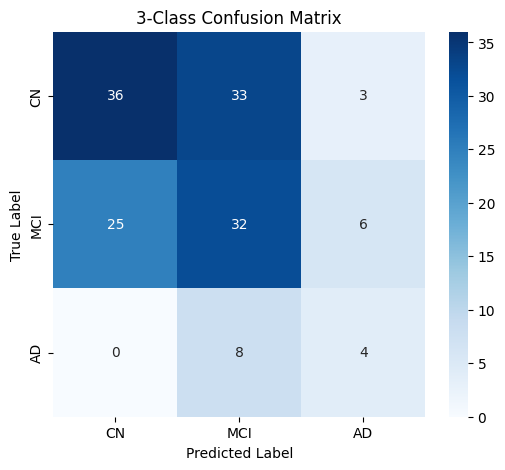

In [15]:
print("--- EVALUATING MODEL ---")
# Load the Model
model = MedicalNetTransfer().to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / "medicalnet_resnet18.pt"))
model.eval()

# Get Test Data
test_loader = get_dataloader("test_sessions", config.SPLIT_LAB_CSV, config.PREPROCESSED_DIR, batch_size=4, augment=False)

all_y_true, all_y_pred, all_y_prob = [], [], []

# Run Inference
with torch.no_grad():
    for x, y, _ in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_y_true.extend(y.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())
        all_y_prob.extend(probs.cpu().numpy())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

# Plot Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CN", "MCI", "AD"], yticklabels=["CN", "MCI", "AD"])
plt.title("3-Class Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [17]:
print("====================================")
print("BINARY TASK EVALUATION (Thresholded)")
print("====================================")
evaluate_binary_task(all_y_true, all_y_prob, 0, 1, "CN", "MCI")
evaluate_binary_task(all_y_true, all_y_prob, 1, 2, "MCI", "AD")
evaluate_binary_task(all_y_true, all_y_prob, 0, 2, "CN", "AD")

BINARY TASK EVALUATION (Thresholded)
--- CN vs MCI ---
Accuracy: 0.5481 | AUC: 0.5926

--- MCI vs AD ---
Accuracy: 0.8133 | AUC: 0.8770

--- CN vs AD ---
Accuracy: 0.7738 | AUC: 0.9155



In [18]:
from captum.attr import LayerGradCam, LayerAttribution
from explainability import plot_gradcam_overlay


def run_explainability(experiment_name="baseline_3dcnn"):
    """
    Generates Grad-CAM heatmaps and calculates localization scores 
    for a specific experiment, saving outputs to a dedicated folder.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(
        f"--- GENERATING Grad-CAM EXPLANATIONS FOR '{experiment_name}' ON {device} ---")

    # Dynamically set the output directory based on the experiment name
    out_dir = config.OUTPUTS_DIR / "explainability" / "gradcam" / experiment_name
    out_dir.mkdir(parents=True, exist_ok=True)

    # Dynamically locate the correct model weights
    model_filename = f"{experiment_name}.pt"
    model_path = config.MODELS_DIR / model_filename

    if not model_path.exists():
        raise FileNotFoundError(
            f"Could not find model weights at {model_path}. Did you run training with EXPERIMENT_NAME='{experiment_name}'?")

    # Load Model (Dynamically choose architecture based on the name)
    if "medicalnet" in experiment_name:
        # pretrained_weights_path=None because then I load MY trained weights
        model = MedicalNetTransfer(pretrained_weights_path=None).to(device)
    else:
        model = EarlyFusion3DCNN(num_classes=3).to(device)

    # load saved weights into the correct architecture
    model.load_state_dict(torch.load(str(model_path), map_location=device))
    model.eval()  # CRITICAL for explanation!

    # Initialize Captum Grad-CAM
    if "medicalnet" in experiment_name:
        # MedicalNet's deepest convolutional layer
        target_layer = model.backbone.layer4
    else:
        # my custom CNN's deepest layer
        target_layer = model.block4

    layer_gc = LayerGradCam(model, target_layer)

    # Load Test Data
    test_loader = get_dataloader(
        "test_sessions", config.SPLIT_LAB_CSV, config.PREPROCESSED_DIR, batch_size=1, augment=False)

    classes = {0: "CN", 1: "MCI", 2: "AD"}
    found_counts = {0: 0, 1: 0, 2: 0}
    target_count = 5

    print("Searching for correctly classified subjects...")

    for batch_x, batch_y, batch_sessions in test_loader:
        if all(count >= target_count for count in found_counts.values()):
            break

        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        true_class = batch_y.item()
        subject_id = batch_sessions[0]

        if found_counts[true_class] >= target_count:
            continue

        # Run inference
        logits = model(batch_x)
        pred_class = torch.argmax(logits, dim=1).item()

        # Only process CORRECTLY classified subjects
        if pred_class == true_class:
            class_name = classes[true_class]
            print(f"[{class_name}] Found match: {subject_id}. Generating heatmap...")

            # --- CAPTUM HEATMAP GENERATION ---
            attribution = layer_gc.attribute(batch_x, target=true_class)
            upsampled_attr = LayerAttribution.interpolate(
                attribution, batch_x.shape[2:])

            heatmap_3d = upsampled_attr.squeeze().cpu().detach().numpy()
            heatmap_3d = np.maximum(heatmap_3d, 0)

            # Grab the original T1 image volume (1st channel of the batch)
            original_volume = batch_x[0, 0].cpu().numpy()
            # Create a 3D binary mask (1 if tissue, 0 if black void)
            brain_mask = (original_volume > 0.01).astype(float)
            # Multiply! This erases all Grad-CAM heat in the empty space.
            heatmap_3d = heatmap_3d * brain_mask

            if np.max(heatmap_3d) > 0:
                heatmap_3d /= np.max(heatmap_3d)

            # --- PLOT AND SAVE THE OVERLAY ---
            save_name = out_dir / f"{class_name}_{subject_id}_gradcam.png"
            plot_gradcam_overlay(batch_x[0], heatmap_3d, str(
                save_name), class_name, subject_id)

            found_counts[true_class] += 1

    print(f"\nFinished! Heatmaps saved to: {out_dir}")

In [19]:
run_explainability(experiment_name="medicalnet_resnet18")

--- GENERATING Grad-CAM EXPLANATIONS FOR 'medicalnet_resnet18' ON cuda ---
Searching for correctly classified subjects...
[CN] Found match: 003_S_10622_sc. Generating heatmap...
[CN] Found match: 005_S_10101_sc. Generating heatmap...
[CN] Found match: 007_S_10258_sc. Generating heatmap...
[CN] Found match: 011_S_10261_sc. Generating heatmap...
[MCI] Found match: 011_S_10483_sc. Generating heatmap...
[CN] Found match: 011_S_7112_init. Generating heatmap...
[MCI] Found match: 016_S_10885_sc. Generating heatmap...
[MCI] Found match: 022_S_10361_sc. Generating heatmap...
[MCI] Found match: 023_S_4115_init. Generating heatmap...
[MCI] Found match: 023_S_4115_m12. Generating heatmap...
[AD] Found match: 033_S_10049_sc. Generating heatmap...
[AD] Found match: 381_S_10511_sc. Generating heatmap...
[AD] Found match: 389_S_10676_sc. Generating heatmap...
[AD] Found match: 941_S_10001_sc. Generating heatmap...

Finished! Heatmaps saved to: C:\Users\leoma\Desktop\Computer Vision\Project\outputs\ex

In [20]:
generate_submission(experiment_name="medicalnet_resnet18")

--- GENERATING FINAL SUBMISSIONS FOR 'medicalnet_resnet18' ON cuda ---
All constraints verified successfully.
Saved Ternary CSV to: medicalnet_resnet18/submission_ternary.csv
Saved Binary CSV: submission_binary_CN_vs_MCI.csv
Saved Binary CSV: submission_binary_MCI_vs_AD.csv
Saved Binary CSV: submission_binary_CN_vs_AD.csv

FINAL TEST SET EVALUATION: medicalnet_resnet18
Accuracy:           0.4898
Balanced Accuracy:  0.4471
Macro Precision:    0.4454
Macro Recall:       0.4471
Macro F1-Score:     0.4440
Macro Specificity:  0.7040
AUC (OVR):          0.6929

